# Unit-4 Regression - Model Training & Evaluation

Linear regression is a statistical method used to model the relationship between a dependent variable 
and one or more independent variables. 

The goal of linear regression is to find the best-fitting line (or hyperplane in higher dimensions) 
that describes the relationship between the variables.

**Key Concepts**

**Dependent Variable (Y):** The outcome or the variable we are trying to predict or explain.

**Independent Variables (X):** The predictors or the variables we use to predict the dependent variable.

**Linear Relationship:** The relationship between the dependent and independent variables is assumed to be linear.

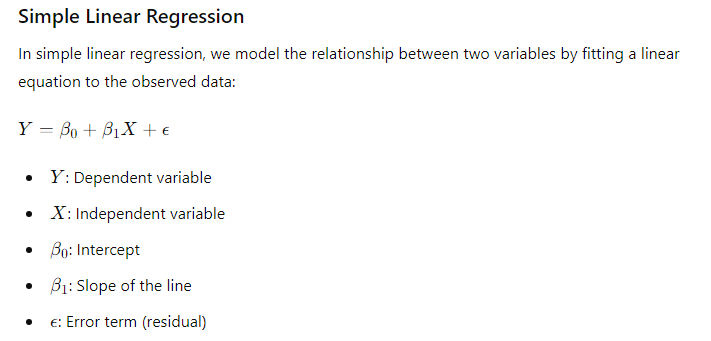

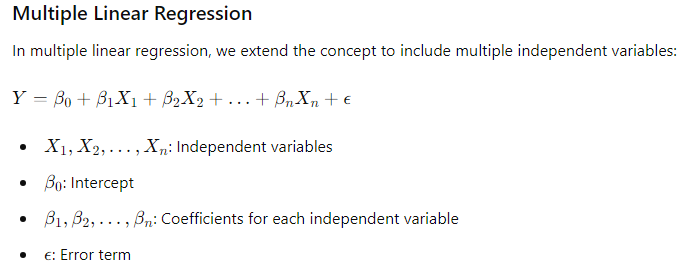

# Polynomial Regression

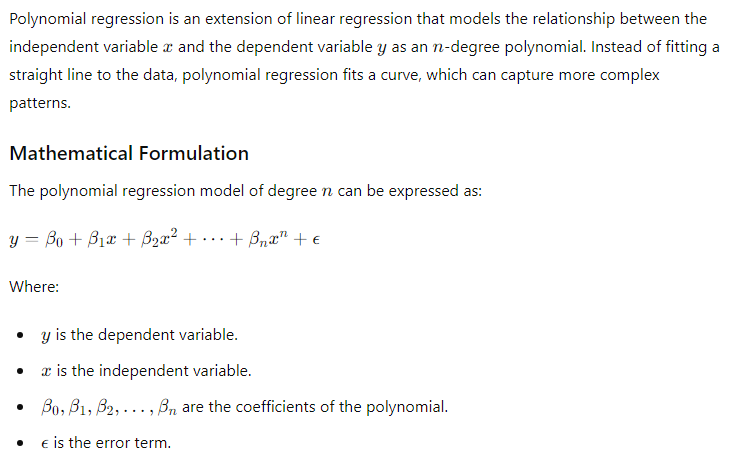

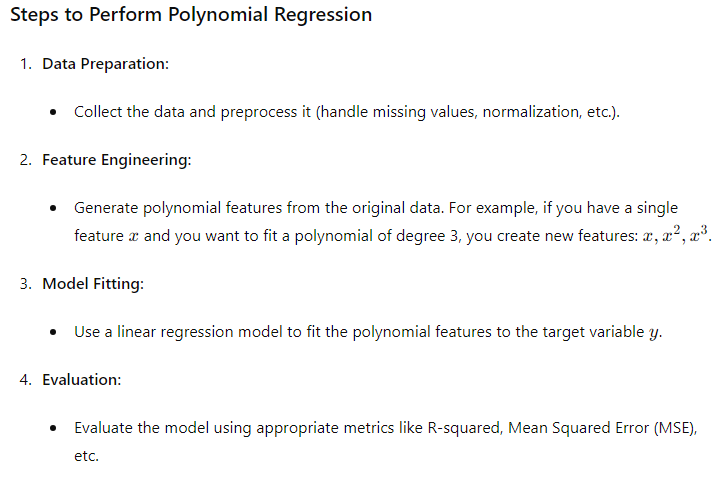

# Simple Linear Regression

### Model-1 - Book1.csv

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

dataset=pd.read_csv('Book1.csv')
dataset

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57
...,...,...
195,6.93,2.46
196,5.89,2.57
197,7.21,3.24
198,7.63,3.96


In [2]:
dataset.isna().sum()

cgpa       0
package    0
dtype: int64

In [3]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   cgpa     200 non-null    float64
 1   package  200 non-null    float64
dtypes: float64(2)
memory usage: 3.3 KB


In [4]:
# Function to Remove the Outliers
def remove_outliers(ds, col):
    quart1 = ds[col].quantile(0.25)
    quart3 = ds[col].quantile(0.75)
    IQR = quart3 - quart1 #Interquartile range
    low_val = quart1 - 1.5*IQR
    print(low_val)
    high_val = quart3 + 1.5*IQR
    print(high_val)
    df_out = ds.loc[(ds[col] >= low_val) & (ds[col] <= high_val)]
    return df_out

dataset = remove_outliers(dataset, 'cgpa')
print(dataset)
dataset = remove_outliers(dataset, 'package')
print(dataset)


3.86875
10.058750000000002
     cgpa  package
0    6.89     3.26
1    5.12     1.98
2    7.82     3.25
3    7.42     3.67
4    6.94     3.57
..    ...      ...
195  6.93     2.46
196  5.89     2.57
197  7.21     3.24
198  7.63     3.96
199  6.22     2.33

[200 rows x 2 columns]
0.9800000000000004
5.0
     cgpa  package
0    6.89     3.26
1    5.12     1.98
2    7.82     3.25
3    7.42     3.67
4    6.94     3.57
..    ...      ...
195  6.93     2.46
196  5.89     2.57
197  7.21     3.24
198  7.63     3.96
199  6.22     2.33

[200 rows x 2 columns]


In [5]:
x=dataset.iloc[:,0:1]
y=dataset.iloc[:,-1]

In [6]:
print(x.shape)
print(y.shape)

(200, 1)
(200,)


In [7]:
print(type(x))
print(type(y))

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.series.Series'>


In [8]:
#Split the data in training & testing
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=2)

print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(160, 1)
(40, 1)
(160,)
(40,)


In [9]:
#Creating LinearRegression Model

from sklearn.linear_model import LinearRegression
lr=LinearRegression()

lr.fit(x_train,y_train)

y_pred=lr.predict(x_test)
print(y_pred)

[3.89111601 3.09324469 2.38464568 2.57434935 1.6537286  1.77647803
 2.07219258 2.93143862 3.76278706 2.93701814 4.09197872 3.51170867
 2.97049525 2.40138424 3.18809652 3.46707251 1.94386362 3.24389172
 2.97607477 3.41685683 2.55761079 3.16577844 2.85890486 3.12114229
 3.68467378 2.8700639  3.49497011 3.34432308 3.91901361 1.96060218
 3.65119666 3.2104146  3.74046898 2.7863711  2.78079158 3.27178932
 3.52844723 2.61340599 2.65804215 2.71383735]


In [10]:
diff=pd.DataFrame({"Actual":y_test,"Predicted":y_pred})
print(diff)

     Actual  Predicted
112    4.10   3.891116
29     3.49   3.093245
182    2.08   2.384646
199    2.33   2.574349
193    1.94   1.653729
85     1.48   1.776478
10     1.86   2.072193
54     3.09   2.931439
115    4.21   3.762787
35     2.87   2.937018
12     3.65   4.091979
92     4.00   3.511709
13     2.89   2.970495
126    2.60   2.401384
174    2.99   3.188097
2      3.25   3.467073
44     1.86   1.943864
3      3.67   3.243892
113    2.37   2.976075
14     3.42   3.416857
23     2.48   2.557611
25     3.65   3.165778
6      2.60   2.858905
134    2.83   3.121142
165    4.08   3.684674
173    2.56   2.870064
45     3.58   3.494970
65     3.81   3.344323
48     4.09   3.919014
122    2.01   1.960602
178    3.63   3.651197
64     2.92   3.210415
9      3.51   3.740469
57     1.94   2.786371
78     2.21   2.780792
71     3.34   3.271789
128    3.34   3.528447
176    3.23   2.613406
131    2.01   2.658042
53     2.61   2.713837


In [11]:
print("Coefficient:",lr.coef_)
print("Intercept:",lr.intercept_)

Coefficient: [0.55795197]
Intercept: -0.8961119222429166


In [12]:
from sklearn import metrics
print("MAE: ",metrics.mean_absolute_error(y_test,y_pred))
print("MSE: ",metrics.mean_squared_error(y_test,y_pred))
print("R2 Score: ",metrics.r2_score(y_test,y_pred))

MAE:  0.2884710931878174
MSE:  0.12129235313495523
R2 Score:  0.7807301475103842


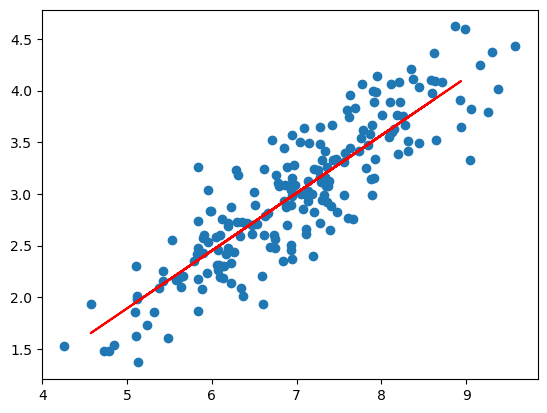

In [13]:
plt.scatter(dataset["cgpa"],dataset["package"])
plt.plot(x_test,y_pred,color="red")
plt.show()

<Axes: xlabel='cgpa', ylabel='package'>

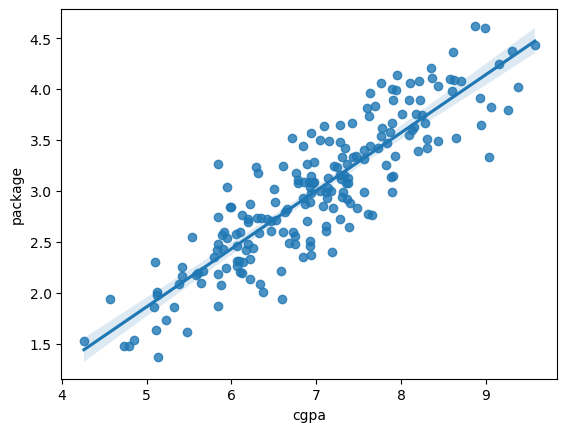

In [14]:
import seaborn as sns
sns.regplot(data=dataset, x="cgpa", y="package")

### Model-2 Olympic100m.csv

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df=pd.read_csv("olympic100m.csv")
df

,year,time
0,1896,12.00
1,1900,11.00
2,1904,11.00
3,1906,11.20
4,1908,10.80
5,1912,10.80
6,1920,10.80
7,1924,10.60
8,1928,10.80
9,1932,10.30


In [16]:
df.isna().sum()

year    0
time    0
dtype: int64

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29 entries, 0 to 28
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   year    29 non-null     int64  
 1   time    29 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 596.0 bytes


In [18]:
# Format data into correct shape
x = df['year']
x_train = np.array(x).reshape((-1, 1)) #To make it 2 dimension array (Data Frame)
x_train.shape

(29, 1)

In [19]:
# Format data into correct shape
y = df['time']
y_train = np.array(y) #To make it 1 dimension array (Data Frame)
y_train.shape

(29,)

In [20]:
from sklearn.linear_model import LinearRegression

# Let's create the model object using LinearRegression
model = LinearRegression()

# Fit our model to our input data x and y
model.fit(x_train, y_train)

y_pred = model.predict(x_train) #Same training data used for prediction
print(y_pred)


[11.12455601 11.07301534 11.02147467 10.99570434 10.969934   10.91839333
 10.81531199 10.76377132 10.71223065 10.66068998 10.60914931 10.45452731
 10.40298664 10.35144597 10.2999053  10.24836463 10.19682396 10.14528329
 10.09374262 10.04220195  9.99066128  9.93912061  9.88757994  9.83603927
  9.7844986   9.73295793  9.68141726  9.62987659  9.57833592]


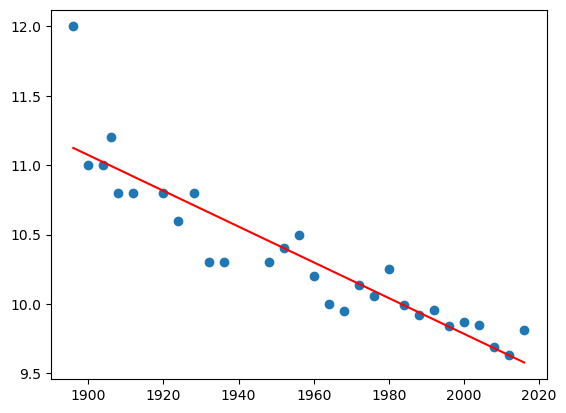

In [21]:
plt.scatter(x_train, y_train)
plt.plot(x, y_pred, color='r')
plt.show()

In [22]:
# Predict for 2020 Olympics

prediction = model.predict([[2020]])
print("The Time prediction for olympic 2020 :",prediction)

The Time prediction for olympic 2020 : [9.52679525]


# Multiple Linear Regression

### Model-3 - car data.csv

In [23]:
#Importing necessary libraries and understanding the data
import pandas as pd
import numpy as np
df=pd.read_csv('car data.csv')
df

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0


**Reading and understanding the dataset**

In [24]:
df.head(20)

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
5,vitara brezza,2018,9.25,9.83,2071,Diesel,Dealer,Manual,0
6,ciaz,2015,6.75,8.12,18796,Petrol,Dealer,Manual,0
7,s cross,2015,6.50,8.61,33429,Diesel,Dealer,Manual,0
8,ciaz,2016,8.75,8.89,20273,Diesel,Dealer,Manual,0
9,ciaz,2015,7.45,8.92,42367,Diesel,Dealer,Manual,0


In [25]:
df.shape

(301, 9)

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [27]:
df.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [28]:
df.isna().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

**Data Preprocessing**

In [29]:
#Adding New Feature for Age - Feature Engineering
df['Age']=2024-df['Year']

#Drop Year Column
df.drop('Year', axis = 1, inplace=True)

In [30]:
df

,Car_Name,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Age
0,ritz,3.35,5.59,27000,Petrol,Dealer,Manual,0,10
1,sx4,4.75,9.54,43000,Diesel,Dealer,Manual,0,11
2,ciaz,7.25,9.85,6900,Petrol,Dealer,Manual,0,7
3,wagon r,2.85,4.15,5200,Petrol,Dealer,Manual,0,13
4,swift,4.60,6.87,42450,Diesel,Dealer,Manual,0,10
...,...,...,...,...,...,...,...,...,...
296,city,9.50,11.60,33988,Diesel,Dealer,Manual,0,8
297,brio,4.00,5.90,60000,Petrol,Dealer,Manual,0,9
298,city,3.35,11.00,87934,Petrol,Dealer,Manual,0,15
299,city,11.50,12.50,9000,Diesel,Dealer,Manual,0,7


**Data Preparation**

Creating dummie variables for categorical features

In [31]:
df.drop(labels='Car_Name', axis=1, inplace=True)
df.head()

,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Age
0,3.35,5.59,27000,Petrol,Dealer,Manual,0,10
1,4.75,9.54,43000,Diesel,Dealer,Manual,0,11
2,7.25,9.85,6900,Petrol,Dealer,Manual,0,7
3,2.85,4.15,5200,Petrol,Dealer,Manual,0,13
4,4.60,6.87,42450,Diesel,Dealer,Manual,0,10


In [ ]:
#Alternate Methods for drop Car_Name
df.drop('Car_Name',axis=1,inplace=True)

In [ ]:
#Alternate Methods for drop Car_Name
df.drop(columns='Car_Name', inplace=True)

In [32]:
#One Hot Encoding - get_dummies function of pandas can be used to dummy code categorical variables
df=pd.get_dummies(data=df, drop_first=True)
df.head()

,Selling_Price,Present_Price,Kms_Driven,Owner,Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
0,3.35,5.59,27000,0,10,False,True,False,True
1,4.75,9.54,43000,0,11,True,False,False,True
2,7.25,9.85,6900,0,7,False,True,False,True
3,2.85,4.15,5200,0,13,False,True,False,True
4,4.60,6.87,42450,0,10,True,False,False,True


In [33]:
df.corr(numeric_only=True)

,Selling_Price,Present_Price,Kms_Driven,Owner,Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
Selling_Price,1.000000,0.878983,0.029187,-0.088344,-0.236141,0.552339,-0.540571,-0.550724,-0.367128
Present_Price,0.878983,1.000000,0.203647,0.008057,0.047584,0.473306,-0.465244,-0.512030,-0.348715
Kms_Driven,0.029187,0.203647,1.000000,0.089216,0.524342,0.172515,-0.172874,-0.101419,-0.162510
Owner,-0.088344,0.008057,0.089216,1.000000,0.182104,-0.053469,0.055687,0.124269,-0.050316
Age,-0.236141,0.047584,0.524342,0.182104,1.000000,-0.064315,0.059959,0.039896,-0.000394
Fuel_Type_Diesel,0.552339,0.473306,0.172515,-0.053469,-0.064315,1.000000,-0.979648,-0.350467,-0.098643
Fuel_Type_Petrol,-0.540571,-0.465244,-0.172874,0.055687,0.059959,-0.979648,1.000000,0.358321,0.091013
Seller_Type_Individual,-0.550724,-0.512030,-0.101419,0.124269,0.039896,-0.350467,0.358321,1.000000,0.063240
Transmission_Manual,-0.367128,-0.348715,-0.162510,-0.050316,-0.000394,-0.098643,0.091013,0.063240,1.000000


In [34]:
df.columns

Index(['Selling_Price', 'Present_Price', 'Kms_Driven', 'Owner', 'Age',
       'Fuel_Type_Diesel', 'Fuel_Type_Petrol', 'Seller_Type_Individual',
       'Transmission_Manual'],
      dtype='object')

**Splitting dataset into train and test subsets**

In [35]:
#y-prediction so dataseries , x- dataframe because multiple columns
y=df['Selling_Price']
x=df.drop('Selling_Price', axis=1)

In [36]:
x

,Present_Price,Kms_Driven,Owner,Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
0,5.59,27000,0,10,False,True,False,True
1,9.54,43000,0,11,True,False,False,True
2,9.85,6900,0,7,False,True,False,True
3,4.15,5200,0,13,False,True,False,True
4,6.87,42450,0,10,True,False,False,True
...,...,...,...,...,...,...,...,...
296,11.60,33988,0,8,True,False,False,True
297,5.90,60000,0,9,False,True,False,True
298,11.00,87934,0,15,False,True,False,True
299,12.50,9000,0,7,True,False,False,True


In [37]:
y

0       3.35
1       4.75
2       7.25
3       2.85
4       4.60
       ...  
296     9.50
297     4.00
298     3.35
299    11.50
300     5.30
Name: Selling_Price, Length: 301, dtype: float64

In [38]:
x.shape

(301, 8)

In [39]:
y.shape

(301,)

In [40]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=1)

In [41]:
print("x train: ", x_train.shape)
print("x test: ", x_test.shape)
print("y train: ", y_train.shape)
print("y test: ",y_test.shape)

x train:  (240, 8)
x test:  (61, 8)
y train:  (240,)
y test:  (61,)


**Creating models (Evaluation)**

In [42]:
from sklearn.linear_model import LinearRegression
lm = LinearRegression()

model = lm.fit(x_train, y_train)

y_pred = model.predict(x_test)
print(y_pred)

[ 7.86273200e+00  2.96828691e+00 -5.90305107e-01  4.21335952e+00
  4.83175534e-01  5.82053813e+00  1.95679784e+00  2.55809661e+00
  7.70870833e+00  9.78692192e-01  8.13484343e+00  3.51207180e+00
  4.90669281e+00  4.63905587e+00 -2.15886643e+00  3.13874624e+00
  7.98256903e+00  6.75937638e+00  6.90426580e+00  8.01440587e+00
  4.31168610e+00  4.00336757e+00  1.13040883e+01  8.07939189e+00
  9.54399823e+00  3.52133877e+00  3.80609808e+00  1.06074722e+00
 -6.01732475e-01 -6.19712043e-01  1.32818516e-03 -1.28500691e+00
  4.28533553e+00  2.06769487e+01  1.87563232e+01  4.27292100e+00
  3.48602852e+00  1.66739677e+00 -4.38707073e-02  5.78536030e+00
  8.03940428e+00  9.88367483e+00  4.09684249e-01  6.07997517e+00
  5.88038915e+00  4.32745252e+00  7.37534505e+00  5.86171335e+00
  8.21129880e+00  1.65455816e+00  3.83033706e+00  1.75047060e+00
  2.51406796e+00  4.20404709e+00  1.48991546e+00 -3.44185843e+00
  2.04806215e+01  6.62503544e-01  5.40027412e+00  5.65856241e+00
  6.47876234e-01]


In [43]:
diff=pd.DataFrame({"Actual":y_test,"Predicted":y_pred})
print(diff)

     Actual  Predicted
285    7.40   7.862732
248    4.00   2.968287
150    0.50  -0.590305
217    3.15   4.213360
107    1.25   0.483176
..      ...        ...
62    18.75  20.480622
154    0.50   0.662504
218    6.45   5.400274
286    5.65   5.658562
186    0.25   0.647876

[61 rows x 2 columns]


In [44]:
x.columns

Index(['Present_Price', 'Kms_Driven', 'Owner', 'Age', 'Fuel_Type_Diesel',
       'Fuel_Type_Petrol', 'Seller_Type_Individual', 'Transmission_Manual'],
      dtype='object')

In [45]:
#To get the Coefficient & Intercept
print('Coefficients:  ', model.coef_)
print('Intercept:  ', model.intercept_)

Coefficients:   [ 4.37233976e-01 -5.30613944e-06  3.45912849e-01 -4.13270098e-01
  2.23050770e+00  4.58549217e-01 -1.20927814e+00 -1.87014327e+00]
Intercept:   7.073759933489662


In [46]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test,y_pred)
r2 = r2_score(y_test, y_pred)

print('Mean squared error:', mse)
print('Mean absolute error:', mae)
print('Coefficient of determination (R^2):', r2)

Mean squared error: 2.98238486185975
Mean absolute error: 1.0998575552990952
Coefficient of determination (R^2): 0.8625260513315252


**Prediction for specific data provided**

In [47]:
x.columns

Index(['Present_Price', 'Kms_Driven', 'Owner', 'Age', 'Fuel_Type_Diesel',
       'Fuel_Type_Petrol', 'Seller_Type_Individual', 'Transmission_Manual'],
      dtype='object')

In [48]:
prediction = model.predict([[5.5,30000,0,10,0,1,1,1]])
print("Predicted Value for Car for given Data: ",prediction)

Predicted Value for Car for given Data:  [2.56578944]


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


### Model-4 - Advertising.csv

In [49]:
import pandas as pd
dataset=pd.read_csv("Advertising.csv")
dataset.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [50]:
dataset.isna().sum() # to check if na is there in data or not

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

In [51]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [52]:
x=dataset[["TV","Radio","Newspaper"]]
y=dataset["Sales"]
print(x.shape)
print(y.shape)

(200, 3)
(200,)


In [53]:
#To check the type of x & y
print(type(x))
print(type(y))

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.series.Series'>


In [54]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=1)

In [55]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(160, 3)
(40, 3)
(160,)
(40,)


In [56]:
from sklearn.linear_model import LinearRegression
lm=LinearRegression()

lm.fit(x_train,y_train)

y_pred=lm.predict(x_test)

In [57]:
diff=pd.DataFrame({"Actual":y_test,"Predicted":y_pred})
diff

,Actual,Predicted
58,23.8,21.327278
40,16.6,18.061384
34,11.9,10.046303
102,19.8,21.092542
184,17.6,20.785275
198,25.5,24.527870
95,16.9,16.841803
4,17.9,15.656542
29,10.5,10.138780
168,17.1,18.882480


In [58]:
#To get the Coefficient & Intercept
print('Coefficients:  ', lm.coef_)
print('Intercept:  ', lm.intercept_)

Coefficients:   [ 0.05507865  0.10308563 -0.00090115]
Intercept:   4.637624442397916


In [59]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test,y_pred)
r2 = r2_score(y_test, y_pred)

print('Mean squared error:', mse)
print('Mean absolute error:', mae)
print('Coefficient of determination (R2 Score):', r2)

Mean squared error: 2.4093336128923672
Mean absolute error: 1.2754390912939682
Coefficient of determination (R2 Score): 0.8747226291661847


### Model-5 insurance.csv

In [60]:
import pandas as pd
df=pd.read_csv("insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,expenses
0,19,female,27.9,0,yes,southwest,16884.92
1,18,male,33.8,1,no,southeast,1725.55
2,28,male,33.0,3,no,southeast,4449.46
3,33,male,22.7,0,no,northwest,21984.47
4,32,male,28.9,0,no,northwest,3866.86


In [61]:
 df.isna().sum() # to check if na is there in data or not

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
expenses    0
dtype: int64

In [62]:
#Creating dummie variables for categorical features**
df=pd.get_dummies(data=df,drop_first=True)
df.head()

,age,bmi,children,expenses,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.9,0,16884.92,False,True,False,False,True
1,18,33.8,1,1725.55,True,False,False,True,False
2,28,33.0,3,4449.46,True,False,False,True,False
3,33,22.7,0,21984.47,True,False,True,False,False
4,32,28.9,0,3866.86,True,False,True,False,False


In [63]:
x=df[["age","bmi","smoker_yes"]]
y=df["expenses"]
print(x.shape)
print(y.shape)

(1338, 3)
(1338,)


In [64]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=1)

print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(1070, 3)
(268, 3)
(1070,)
(268,)


In [65]:
from sklearn.linear_model import LinearRegression
lm=LinearRegression() 
lm.fit(x_train,y_train)
y_pred=lm.predict(x_test)

In [66]:
diff=pd.DataFrame({"Actual":y_test,"Predicted":y_pred})
diff

,Actual,Predicted
559,1646.43,4637.513777
1087,11353.23,13263.376708
1020,8798.59,13378.823508
460,10381.48,12739.553621
802,2103.08,1149.576521
...,...,...
682,40103.89,33478.481582
629,42983.46,35896.028305
893,44202.65,36642.503356
807,2136.88,4971.332002


In [67]:
print(lm.coef_)
print(lm.intercept_)

[  258.94072065   303.47111341 23722.84761499]
-11055.58444147595


In [68]:
from sklearn import metrics
print("MAE: ",metrics.mean_absolute_error(y_test,y_pred))
print("MSE: ",metrics.mean_squared_error(y_test,y_pred))
print("Coefficient of Determination (R2 Score): ",r2_score(y_test,y_pred))

MAE:  4107.492142539743
MSE:  36305111.19360471
Coefficient of Determination (R2 Score):  0.7567996129313421


### Model-6 - FuelConsumptionCo2.csv

In [83]:
import pandas as pd
data=pd.read_csv('FuelConsumptionCo2.csv')
data

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2014,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,2014,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,2014,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,2014,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,2014,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1062,2014,VOLVO,XC60 AWD,SUV - SMALL,3.0,6,AS6,X,13.4,9.8,11.8,24,271
1063,2014,VOLVO,XC60 AWD,SUV - SMALL,3.2,6,AS6,X,13.2,9.5,11.5,25,264
1064,2014,VOLVO,XC70 AWD,SUV - SMALL,3.0,6,AS6,X,13.4,9.8,11.8,24,271
1065,2014,VOLVO,XC70 AWD,SUV - SMALL,3.2,6,AS6,X,12.9,9.3,11.3,25,260


In [84]:
#Removing columns which is of no use for model making

In [85]:
data.drop(columns=['MAKE','MODEL','VEHICLECLASS','TRANSMISSION','FUELTYPE'],axis=1,inplace=True)

In [86]:
data

,MODELYEAR,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2014,2.0,4,9.9,6.7,8.5,33,196
1,2014,2.4,4,11.2,7.7,9.6,29,221
2,2014,1.5,4,6.0,5.8,5.9,48,136
3,2014,3.5,6,12.7,9.1,11.1,25,255
4,2014,3.5,6,12.1,8.7,10.6,27,244
...,...,...,...,...,...,...,...,...
1062,2014,3.0,6,13.4,9.8,11.8,24,271
1063,2014,3.2,6,13.2,9.5,11.5,25,264
1064,2014,3.0,6,13.4,9.8,11.8,24,271
1065,2014,3.2,6,12.9,9.3,11.3,25,260


In [87]:
#Converting Model year to age column
data['Age']=2023-data['MODELYEAR']

data.drop(labels='MODELYEAR',axis=1,inplace=True)
data

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS,Age
0,2.0,4,9.9,6.7,8.5,33,196,9
1,2.4,4,11.2,7.7,9.6,29,221,9
2,1.5,4,6.0,5.8,5.9,48,136,9
3,3.5,6,12.7,9.1,11.1,25,255,9
4,3.5,6,12.1,8.7,10.6,27,244,9
...,...,...,...,...,...,...,...,...
1062,3.0,6,13.4,9.8,11.8,24,271,9
1063,3.2,6,13.2,9.5,11.5,25,264,9
1064,3.0,6,13.4,9.8,11.8,24,271,9
1065,3.2,6,12.9,9.3,11.3,25,260,9


In [88]:
pd.get_dummies(data,drop_first=True)

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS,Age
0,2.0,4,9.9,6.7,8.5,33,196,9
1,2.4,4,11.2,7.7,9.6,29,221,9
2,1.5,4,6.0,5.8,5.9,48,136,9
3,3.5,6,12.7,9.1,11.1,25,255,9
4,3.5,6,12.1,8.7,10.6,27,244,9
...,...,...,...,...,...,...,...,...
1062,3.0,6,13.4,9.8,11.8,24,271,9
1063,3.2,6,13.2,9.5,11.5,25,264,9
1064,3.0,6,13.4,9.8,11.8,24,271,9
1065,3.2,6,12.9,9.3,11.3,25,260,9


In [90]:
#Checking for corelation between parameters then we choose columns for x & y
data.corr(numeric_only=True)

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS,Age
ENGINESIZE,1.000000,0.934011,0.832225,0.778746,0.819482,-0.808554,0.874154,NaN
CYLINDERS,0.934011,1.000000,0.796473,0.724594,0.776788,-0.770430,0.849685,NaN
FUELCONSUMPTION_CITY,0.832225,0.796473,1.000000,0.965718,0.995542,-0.935613,0.898039,NaN
FUELCONSUMPTION_HWY,0.778746,0.724594,0.965718,1.000000,0.985804,-0.893809,0.861748,NaN
FUELCONSUMPTION_COMB,0.819482,0.776788,0.995542,0.985804,1.000000,-0.927965,0.892129,NaN
FUELCONSUMPTION_COMB_MPG,-0.808554,-0.770430,-0.935613,-0.893809,-0.927965,1.000000,-0.906394,NaN
CO2EMISSIONS,0.874154,0.849685,0.898039,0.861748,0.892129,-0.906394,1.000000,NaN
Age,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**We are Choosing Engine Size,Cylinders & Fuelconsumsion_Comb for X and Predicting the
 CO2Emissions**

In [91]:
x=data[['ENGINESIZE','CYLINDERS','FUELCONSUMPTION_COMB']]
y=data['CO2EMISSIONS']

In [92]:
print(x.shape)
print(y.shape)

(1067, 3)
(1067,)


In [94]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=1)

print("x train: ", x_train.shape)
print("x test: ", x_test.shape)
print("y train: ", y_train.shape)
print("y test: ",y_test.shape)

x train:  (853, 3)
x test:  (214, 3)
y train:  (853,)
y test:  (214,)


In [95]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x_train,y_train)
y_pred=lr.predict(x_test)
y_pred

array([257.0729753 , 193.62675365, 198.61947156, 184.0315625 ,
       308.84886971, 222.06199356, 185.00408977, 193.38929893,
       234.70484808, 197.40948958, 217.83256226, 260.96308439,
       200.32707139, 363.64971908, 200.51083953, 192.73062136,
       193.99428993, 314.31649706, 261.88192508, 215.88750772,
       440.76775066, 216.07127586, 254.46924319, 258.96434327,
       279.75495223, 239.56748443, 162.03372438, 288.13465573,
       187.18659903, 231.68539877, 229.84221172, 367.53982816,
       246.32148875, 360.70666476, 285.37813365, 315.9704103 ,
       351.66277803, 181.16766727, 341.17972436, 257.62427972,
       239.56748443, 373.66062742, 215.15243517, 257.20305686,
       256.41429773, 201.53705338, 189.73664457, 161.53335371,
       181.11398069, 250.02782969, 189.13165357, 336.15602827,
       329.4839246 , 344.85508713, 211.26232608, 269.05715225,
       208.29105769, 289.16086958, 263.22198863, 185.24154449,
       209.07981683, 238.80693936, 209.31727154, 194.72

In [96]:
diff=pd.DataFrame({'Actual':y_test,'Predicted':y_pred})
diff

,Actual,Predicted
133,274,257.072975
340,200,193.626754
948,196,198.619472
704,161,184.031563
661,320,308.848870
...,...,...
961,301,275.681075
523,184,189.131654
884,274,266.323339
8,267,262.249461


In [97]:
print(lr.coef_)
print(lr.intercept_)

[11.56295409  6.91231122  9.72527271]
65.17950048137237


In [98]:
from sklearn import metrics
print('MAE: ',metrics.mean_absolute_error(y_test,y_pred))
print('MSE: ',metrics.mean_squared_error(y_test,y_pred))
print('R2 Score: ', metrics.r2_score(y_test,y_pred))

MAE:  16.64682799882323
MSE:  546.259139690344
R2 Score:  0.8653355812644816


### Prediction based on Generating Synthetic Data (Without use of dataset)

In [99]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error,mean_squared_error, r2_score

# Generate synthetic data
x = 2 * np.random.rand(100,1)
y = 4 + 3 * x + np.random.rand(100,1)
print(x)

# Split the data into training/testing sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)

# Create linear regression object
reg = LinearRegression()

# Train the model using the training sets
reg.fit(x_train, y_train)

# Make predictions using the testing set
y_pred = reg.predict(x_test)

# The coefficients
print('Coefficients: ', reg.coef_)
print('Intercept: ', reg.intercept_)


# The mean absolute error
print('Mean squared error: %.2f' % mean_absolute_error(y_test, y_pred))

# The mean squared error
print('Mean squared error: %.2f' % mean_squared_error(y_test, y_pred))

# The coefficient of determination: 1 is perfect prediction
print('Coefficient of determination: %.2f' % r2_score(y_test, y_pred))

[[0.49917366]
 [1.0650438 ]
 [0.70107635]
 [1.93580182]
 [0.9861083 ]
 [1.01984186]
 [0.86712685]
 [0.38274439]
 [0.02480119]
 [0.23155983]
 [0.48852571]
 [0.06855977]
 [1.42176557]
 [1.55035089]
 [1.92238598]
 [0.16490834]
 [0.33581501]
 [1.07696765]
 [1.60310801]
 [0.95101256]
 [1.52293914]
 [1.68243887]
 [0.50706218]
 [0.4418921 ]
 [1.33911691]
 [1.3377579 ]
 [0.42381223]
 [0.3176952 ]
 [0.52247148]
 [1.07514526]
 [0.71890687]
 [0.47739858]
 [1.87766602]
 [0.18671241]
 [1.13872441]
 [0.92492494]
 [0.91937079]
 [1.33632242]
 [1.80885709]
 [0.71705734]
 [1.20464837]
 [0.63837316]
 [0.9406008 ]
 [1.52090453]
 [0.95248913]
 [1.75423412]
 [0.65437481]
 [0.06393499]
 [0.65108702]
 [1.36449962]
 [0.25554244]
 [1.13980427]
 [1.96805184]
 [1.64356242]
 [1.21855558]
 [0.60087708]
 [0.23612985]
 [0.49253696]
 [1.38199553]
 [0.71094341]
 [1.35952258]
 [1.1455072 ]
 [0.71565978]
 [0.08264188]
 [0.58725206]
 [1.11019075]
 [1.79753242]
 [0.71241035]
 [0.55626109]
 [0.91674589]
 [1.26949266]
 [0.26

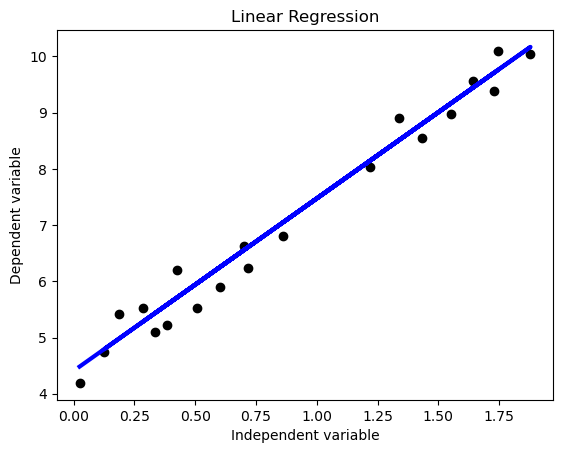

In [100]:
# Plot outputs
plt.scatter(x_test, y_test, color='black')
plt.plot(x_test, y_pred, color='blue', linewidth=3)
plt.xlabel('Independent variable')
plt.ylabel('Dependent variable')
plt.title('Linear Regression')
plt.show()

This code generates synthetic data, splits it into training and testing sets, trains a linear regression model, makes predictions, and evaluates the model's performance.

Linear regression is a fundamental tool in statistics and machine learning, providing a simple yet powerful way to model and understand relationships between variables.

### Polynomial Regression

### Model-7 polylinearregression.csv

In [113]:
# Importing the libraries
# y = a + b_1x + b_2x^2 +....+ b_nx^n    
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Importing the dataset
df = pd.read_csv('polylinearregression.csv')
df

,sno,Temperature,Pressure
0,1,0,0.0002
1,2,20,0.0012
2,3,40,0.0060
3,4,60,0.0300
4,5,80,0.0900
5,6,100,0.2700


In [114]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   sno          6 non-null      int64  
 1   Temperature  6 non-null      int64  
 2   Pressure     6 non-null      float64
dtypes: float64(1), int64(2)
memory usage: 276.0 bytes


In [115]:
df.isna().sum()

sno            0
Temperature    0
Pressure       0
dtype: int64

In [116]:
# Extract our x values, the column Temperature
x = df.iloc[:, 1:2]

# Extract our y or target variable Pressure
y = df.iloc[:, 2]

In [117]:
print(x.shape)
print(y.shape)

(6, 1)
(6,)


In [118]:
# Fitting Polynomial Regression to the dataset
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree = 3)
x_Poly = poly.fit_transform(x)

In [121]:

# Fitting the Polynomial Regression model on two components X and y.
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(x_Poly, y)
y_pred=lr.predict(x_Poly)
y_pred

array([-0.00198889,  0.00724444,  0.00371111,  0.02248889,  0.09865556,
        0.26728889])

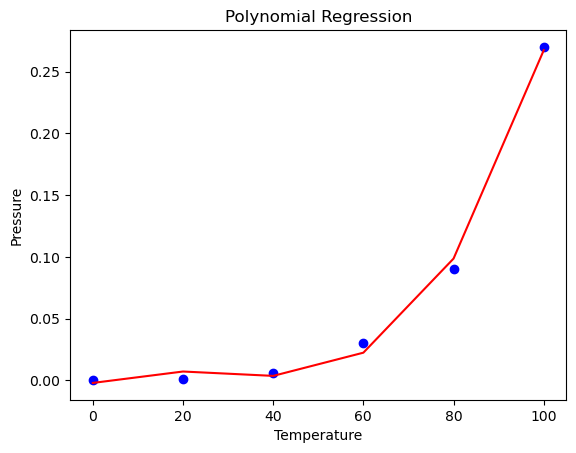

In [122]:
# Visualising the Polynomial Regression results
plt.scatter(x, y, color = 'blue')

plt.plot(x, y_pred, color = 'red')
plt.title('Polynomial Regression')
plt.xlabel('Temperature')
plt.ylabel('Pressure')

plt.show()

In [123]:
# train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y, y_pred))

# train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y, y_pred)

# print(f'Train RMSE: {train_rmse}')
print(f'Test RMSE: {test_rmse}')

# print(f'Train R-squared: {train_r2}')
print(f'Test R-squared: {test_r2}')

Test RMSE: 0.005556544356448986
Test R-squared: 0.9966691251761722


### Model-8 - car_data.csv

In [136]:
import pandas as pd
data=pd.read_csv('car_data.csv')
data

,Horsepower,Weight,MPG
0,130,3504,18
1,165,3693,15
2,150,3436,18
3,140,3433,16
4,198,4341,14
5,220,4354,12
6,95,2372,25
7,88,2130,27
8,98,2228,24


In [137]:
data.isna().sum()

Horsepower    0
Weight        0
MPG           0
dtype: int64

In [138]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Horsepower  9 non-null      int64
 1   Weight      9 non-null      int64
 2   MPG         9 non-null      int64
dtypes: int64(3)
memory usage: 348.0 bytes


In [139]:
# Extract the independent and dependent variables
x = data[['Horsepower', 'Weight']]
y = data['MPG']

In [140]:
print(x.shape)
print(y.shape)

(9, 2)
(9,)


In [141]:
from sklearn.preprocessing import PolynomialFeatures

# Transform the features to polynomial features
polynomial_features = PolynomialFeatures(degree=3)
x_poly=polynomial_features.fit_transform(x)

In [142]:
x_poly

array([[1.00000000e+00, 1.30000000e+02, 3.50400000e+03, 1.69000000e+04,
        4.55520000e+05, 1.22780160e+07, 2.19700000e+06, 5.92176000e+07,
        1.59614208e+09, 4.30221681e+10],
       [1.00000000e+00, 1.65000000e+02, 3.69300000e+03, 2.72250000e+04,
        6.09345000e+05, 1.36382490e+07, 4.49212500e+06, 1.00541925e+08,
        2.25031108e+09, 5.03660536e+10],
       [1.00000000e+00, 1.50000000e+02, 3.43600000e+03, 2.25000000e+04,
        5.15400000e+05, 1.18060960e+07, 3.37500000e+06, 7.73100000e+07,
        1.77091440e+09, 4.05657459e+10],
       [1.00000000e+00, 1.40000000e+02, 3.43300000e+03, 1.96000000e+04,
        4.80620000e+05, 1.17854890e+07, 2.74400000e+06, 6.72868000e+07,
        1.64996846e+09, 4.04595837e+10],
       [1.00000000e+00, 1.98000000e+02, 4.34100000e+03, 3.92040000e+04,
        8.59518000e+05, 1.88442810e+07, 7.76239200e+06, 1.70184564e+08,
        3.73116764e+09, 8.18030238e+10],
       [1.00000000e+00, 2.20000000e+02, 4.35400000e+03, 4.84000000e+04,
   

In [143]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x_poly, y, test_size=0.2, random_state=1)

In [144]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(7, 10)
(2, 10)
(7,)
(2,)


In [145]:
from sklearn.linear_model import LinearRegression
# Fit the linear regression model
model = LinearRegression()
model.fit(x_train, y_train)
# Predict on the testing set
y_pred = model.predict(x_test)
y_pred

array([25.92139147, 16.15742828])

In [147]:
from sklearn.metrics import mean_squared_error, r2_score
# Evaluate the model

# train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_pred)

# print(f'Train R-squared: {train_r2}')
print(f'Test R-squared: {test_r2}')

Test R-squared: 0.6062880150608976


### Model-9 - Iris.csv


In [148]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# Load the iris dataset
iris = pd.read_csv('Iris.csv')
iris

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
95,96,5.7,3.0,4.2,1.2,Iris-versicolor
96,97,5.7,2.9,4.2,1.3,Iris-versicolor
97,98,6.2,2.9,4.3,1.3,Iris-versicolor
98,99,5.1,2.5,3.0,1.1,Iris-versicolor


In [149]:
# Extract the sepal length feature
x = iris[['SepalLengthCm']]

# Extract the petal length feature
y = iris['PetalLengthCm']

In [150]:
print(type(x))
print(type(y))

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.series.Series'>


In [151]:
# Create polynomial features with feature names
poly = PolynomialFeatures(degree=2)
x_poly = poly.fit_transform(x)

In [152]:
# Split the data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x_poly, y, test_size=0.2, random_state=1)

print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_train.shape)

(80, 3)
(20, 3)
(80,)
(80,)


In [153]:
# Create a linear regression model
model = LinearRegression()

# Fit the model on the polynomial features
model.fit(x_train, y_train)

# Generate test data, reshape to a column vector
y_pred = model.predict(x_test)
print(y_pred)


[3.02049398 2.83155393 3.02049398 3.02049398 2.04051999 2.24356954
 3.02049398 3.56614986 3.20590665 5.01263923 3.56614986 2.24356954
 4.40502882 5.29528018 4.56222249 2.44309171 2.83155393 2.24356954
 3.91228358 2.83155393]


In [154]:
# Get the coefficients and intercept
coefficients = model.coef_
intercept = model.intercept_

print("Coefficients (for polynomial features):")
print(coefficients)
print("\nIntercept:")
print(intercept)

Coefficients (for polynomial features):
[ 0.          3.81182023 -0.17636879]

Intercept:
-12.609361502893364


In [156]:
# train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_pred)

# print(f'Train RMSE: {train_rmse}')
print(f'Test RMSE: {test_rmse}')

# print(f'Train R-squared: {train_r2}')
print(f'Test R-squared: {test_r2}')

Test RMSE: 0.964178676700831
Test R-squared: 0.49816298702839956


**Conclusion**

Linear regression, with its variants and extensions, is a powerful and widely-used tool in data analysis and predictive modeling. By understanding the fundamental concepts, assumptions, and techniques for regularization and diagnostics, you can effectively apply linear regression to a wide range of practical problems.